# SHIELD-ID Prototype: Macro Shock Vulnerability Index

Ranks Indonesia's **38 provinces** by their structural vulnerability to the 2026 shock cluster (Strait of Hormuz, US tariffs, IDR depreciation).

## Pipeline
1. Load raw CSVs (BPS provincial + commodities + FX)
2. Build a national monthly commodity panel (Brent, USD/IDR, palm oil, nickel, coal, tin)
3. Compute 5 structural features per province
4. Combine into a weighted composite vulnerability index
5. Project under three shock scenarios (Base / Adverse / Severe)
6. Write CSV / charts / interactive map / markdown report

## Features
| Feature | Formula | Direction |
|---|---|---|
| `hhi_sectoral` | $\sum_s (\text{PDRB}_s / \text{PDRB}_\text{total})^2$ | $\uparrow$ = more vulnerable |
| `export_intensity` | total exports / PDRB | $\uparrow$ = more vulnerable |
| `migas_share` | oil & gas exports / total exports | $\uparrow$ = oil-shock exposed |
| `beta_oil` | OLS slope of inflation on $\Delta\log$(Brent) | $\uparrow$ = oil-shock exposed |
| `beta_fx` | OLS slope of inflation on $\Delta\log$(USD/IDR) | $\uparrow$ = FX-shock exposed |
| `resilience` | mean of z(-poverty), z(-Gini), z(formal employment) | subtracted (higher = LESS vulnerable) |

In [1]:
import os, sys
from pathlib import Path
import pandas as pd
import numpy as np

sys.path.insert(0, os.path.abspath('.'))
import prototype_lib as pl

RAW       = Path('data/raw')
PROCESSED = Path('data/processed'); PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUTS   = Path('outputs');        OUTPUTS.mkdir(parents=True, exist_ok=True)

print('prototype_lib version:', pl.__name__)
print('Default weights:', pl.DEFAULT_WEIGHTS)
print('Default scenarios:', pl.DEFAULT_SCENARIOS)

prototype_lib version: prototype_lib
Default weights: {'hhi_sectoral': 0.2, 'export_intensity': 0.2, 'migas_share': 0.2, 'beta_oil': 0.15, 'beta_fx': 0.15, 'resilience': -0.1}
Default scenarios: {'Base': {'d_oil_pct': 0.0, 'd_fx_pct': 0.0, 'multiplier': 1.0}, 'Adverse': {'d_oil_pct': 0.2, 'd_fx_pct': 0.03, 'multiplier': 1.5}, 'Severe': {'d_oil_pct': 0.4, 'd_fx_pct': 0.06, 'multiplier': 2.0}}


## Stage 1 — Load raw data
All BPS tables share the same long-format schema; `load_bps_csv` normalizes province names/codes and parses Indonesian period labels into dates.

In [2]:
inflation_mom = pl.load_bps_csv(RAW/'bps/bps_inflation_mom.csv')
exp_migas     = pl.load_bps_csv(RAW/'bps/bps_export_migas.csv')
exp_nonmigas  = pl.load_bps_csv(RAW/'bps/bps_export_nonmigas.csv')
pdrb          = pl.load_bps_csv(RAW/'bps/bps_pdrb_adhb_quarterly.csv')
gini          = pl.load_bps_csv(RAW/'bps/bps_gini.csv')
poverty_p1    = pl.load_bps_csv(RAW/'bps/bps_poverty_depth_p1.csv')
emp_status    = pl.load_bps_csv(RAW/'bps/bps_employment_by_status.csv')

for name, df in [('inflation_mom', inflation_mom), ('exp_migas', exp_migas),
                 ('exp_nonmigas', exp_nonmigas), ('pdrb', pdrb), ('gini', gini),
                 ('poverty_p1', poverty_p1), ('emp_status', emp_status)]:
    print(f'  {name:<14} {len(df):>6,} rows  {df["province"].nunique():>2} provinces  '
          f'{df["date"].min().date() if df["date"].notna().any() else "NaT"} to '
          f'{df["date"].max().date() if df["date"].notna().any() else "NaT"}')

  inflation_mom     456 rows  38 provinces  2024-01-01 to 2024-12-01
  exp_migas       1,325 rows  38 provinces  2022-01-01 to 2024-12-01
  exp_nonmigas    1,374 rows  38 provinces  2022-01-01 to 2024-12-01
  pdrb            9,540 rows  38 provinces  2022-03-01 to 2024-12-01
  gini            3,214 rows  38 provinces  2005-12-01 to 2024-09-01
  poverty_p1      3,029 rows  38 provinces  2007-12-01 to 2024-09-01
  emp_status      1,695 rows  38 provinces  2022-02-01 to 2024-08-01


## Stage 2 — National commodity & FX panel
Daily series resampled to monthly mean; sources coalesced (Yahoo + FRED + World Bank Pink Sheet).

In [3]:
commodity_panel = pl.load_commodity_panel(RAW)
print(f'Panel shape: {commodity_panel.shape}')
print(f'Period: {commodity_panel.index.min().date()} to {commodity_panel.index.max().date()}')
commodity_panel.tail(6)

Panel shape: (256, 7)
Period: 2005-01-01 to 2026-04-01


,brent,wti,usd_idr,nickel,coal,palm_oil,tin
date,,,,,,,
2025-11-01,63.679474,59.479474,16676.339941,14670.768500,115.436786,983.40,36963.22
2025-12-01,61.628636,57.866364,16673.640891,14879.030000,115.684286,980.12,41219.52
2026-01-01,64.765499,60.259500,16800.109468,17710.863636,115.815000,1004.66,49538.44
2026-02-01,69.406843,64.523157,16810.730176,17173.103500,122.209286,1039.47,48694.34
2026-03-01,99.599546,90.997272,16902.349964,17076.292727,140.056071,1102.98,47323.68
2026-04-01,99.321333,97.384001,17054.056274,NaN,NaN,NaN,NaN


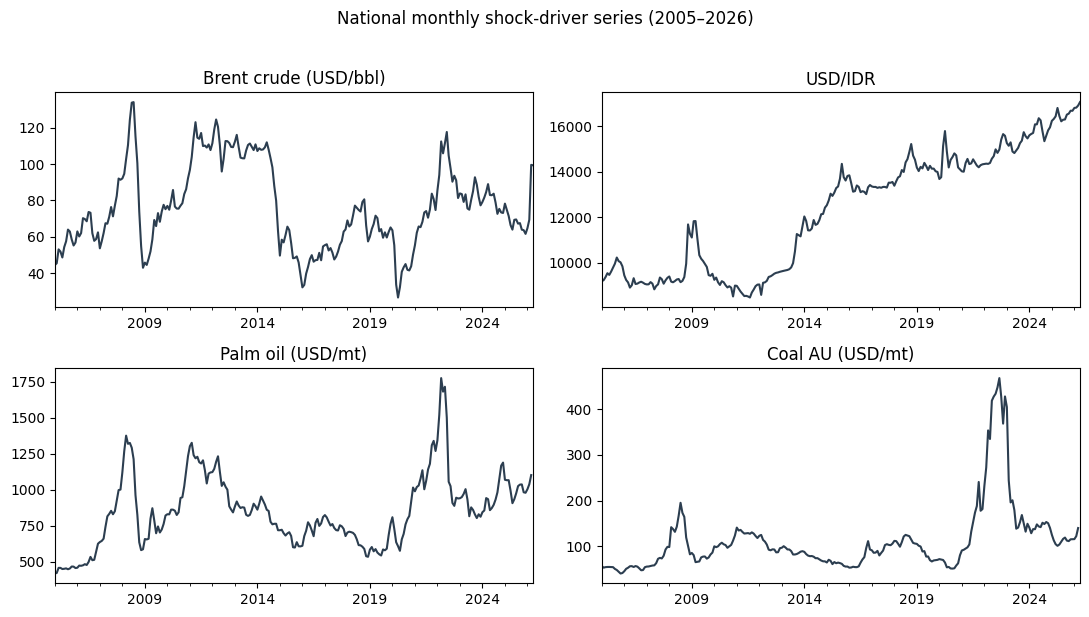

In [4]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(11, 6))
for ax, col, title in zip(axs.flat,
                          ['brent', 'usd_idr', 'palm_oil', 'coal'],
                          ['Brent crude (USD/bbl)', 'USD/IDR', 'Palm oil (USD/mt)', 'Coal AU (USD/mt)']):
    commodity_panel[col].plot(ax=ax, color='#2c3e50')
    ax.set_title(title); ax.set_xlabel('')
fig.suptitle('National monthly shock-driver series (2005–2026)', y=1.02)
fig.tight_layout()

## Stage 3 — Per-province features

In [5]:
hhi   = pl.compute_hhi(pdrb)
expf  = pl.compute_export_features(exp_migas, exp_nonmigas, pdrb)
betas = pl.compute_betas(inflation_mom, commodity_panel)
res   = pl.compute_resilience(poverty_p1, gini, emp_status)

features = pl.build_features_table(hhi, expf, betas, res)
print(f'Feature table: {features.shape}')
features.head()

Feature table: (38, 6)


,hhi_sectoral,export_intensity,migas_share,beta_oil,beta_fx,resilience
province,,,,,,
Aceh,0.287700,1.433613,0.072562,2.175189,3.915815,0.579941
Bali,0.276817,1.060369,0.000417,4.954933,-9.159734,0.350022
Banten,0.287181,6.999210,0.005010,6.215096,-2.306364,0.246761
Bengkulu,0.285129,0.934802,0.000000,-0.797701,10.133974,0.060759
Di Yogyakarta,0.271109,1.412696,0.000000,2.548712,-2.366121,-0.402869


In [6]:
# Quick look — top 5 by each feature dimension
for col in ['hhi_sectoral', 'export_intensity', 'migas_share', 'beta_oil', 'beta_fx']:
    print(f'\n=== Top 5 by {col} ===')
    print(features.nlargest(5, col)[[col]].to_string())


=== Top 5 by hhi_sectoral ===
                 hhi_sectoral
province                     
Papua Tengah         0.399420
Sulawesi Barat       0.311910
Papua Barat          0.309461
Kepulauan Riau       0.307922
Sulawesi Tengah      0.307328

=== Top 5 by export_intensity ===
                    export_intensity
province                            
Maluku Utara               57.128373
Sulawesi Tengah            28.302462
Kepulauan Riau             27.417001
Papua Barat                23.802176
Kalimantan Selatan         20.326681

=== Top 5 by migas_share ===
                  migas_share
province                     
Papua Barat          0.991902
Jambi                0.582272
Papua Barat Daya     0.550460
Maluku               0.245098
Kepulauan Riau       0.128669

=== Top 5 by beta_oil ===
             beta_oil
province             
Banten       6.215096
Jawa Timur   5.043583
Bali         4.954933
Jawa Tengah  3.947088
Jawa Barat   3.603536

=== Top 5 by beta_fx ===
                  

## Stage 4 — Composite index (no shocks applied)
Z-normalize each feature across the 38 provinces, weight, sum, scale to [0, 1].

In [7]:
indexed = pl.compute_index(features)
print('Top 10 most vulnerable (no scenario shock):')
indexed[['vuln_index', 'rank', 'hhi_sectoral', 'migas_share', 'beta_oil', 'beta_fx']].head(10)

Top 10 most vulnerable (no scenario shock):


,vuln_index,rank,hhi_sectoral,migas_share,beta_oil,beta_fx
province,,,,,,
Papua Barat,1.000000,1,0.309461,9.919020e-01,-5.344841,16.849352
Papua Tengah,0.931084,2,0.399420,7.508624e-07,-4.816182,26.139919
Maluku Utara,0.557651,3,0.297643,0.000000e+00,-7.198971,8.593869
Sulawesi Tengah,0.470695,4,0.307328,7.936415e-02,1.629845,1.491024
Kepulauan Riau,0.452821,5,0.307922,1.286690e-01,-3.646711,11.944774
Jambi,0.396391,6,0.292926,5.822720e-01,-0.063245,8.097796
Papua Barat Daya,0.374269,7,0.279399,5.504597e-01,0.892928,-0.942203
Kalimantan Timur,0.313116,8,0.302660,9.845054e-02,0.310691,6.350061
Kalimantan Selatan,0.256882,9,0.284921,0.000000e+00,0.927199,10.589543


## Stage 5 — Scenario simulation
Each scenario layers an oil-price and FX shock on top of the structural index, scaled by each province's β coefficients.

In [8]:
scenario_df = pl.apply_scenarios(features)
print(f'Scenario output: {scenario_df.shape} (38 provinces × 3 scenarios = 114 rows expected)')

# Pivoted view: each province's score across scenarios
pivot = scenario_df.pivot(index='province', columns='scenario', values='score').round(3)
pivot = pivot[['Base', 'Adverse', 'Severe']].sort_values('Severe', ascending=False)
pivot.head(15)

Scenario output: (114, 11) (38 provinces × 3 scenarios = 114 rows expected)


scenario,Base,Adverse,Severe
province,,,
Banten,0.660,0.787,1.000
Jawa Timur,0.660,0.755,0.915
Jawa Barat,0.671,0.741,0.858
Jawa Tengah,0.659,0.734,0.857
Bali,0.635,0.713,0.843
Kalimantan Selatan,0.671,0.726,0.817
Aceh,0.651,0.711,0.811
Kalimantan Utara,0.648,0.709,0.810
Sulawesi Tengah,0.701,0.741,0.809


## Stage 6 — Persist outputs

In [9]:
# Master panel — long-form record of every (province, source) value used
master = pd.concat([
    inflation_mom.assign(metric='inflation_mom'),
    exp_migas.assign(metric='export_migas'),
    exp_nonmigas.assign(metric='export_nonmigas'),
    pdrb.assign(metric='pdrb_adhb_quarterly'),
    gini.assign(metric='gini'),
    poverty_p1.assign(metric='poverty_p1'),
    emp_status.assign(metric='employment_status'),
], ignore_index=True)
master_path = PROCESSED/'master_panel.csv'
master.to_csv(master_path, index=False)
print(f'Master panel:        {len(master):,} rows -> {master_path}')

# Features table — one row per province, all features incl. z-scores
feat_path = PROCESSED/'vulnerability_features.csv'
indexed.reset_index().to_csv(feat_path, index=False)
print(f'Features:            {len(indexed):,} rows -> {feat_path}')

# Final index — primary deliverable
idx_path = PROCESSED/'vulnerability_index.csv'
scenario_df.to_csv(idx_path, index=False)
print(f'Vulnerability index: {len(scenario_df):,} rows -> {idx_path}')

Master panel:        20,633 rows -> data\processed\master_panel.csv
Features:            38 rows -> data\processed\vulnerability_features.csv
Vulnerability index: 114 rows -> data\processed\vulnerability_index.csv


In [10]:
for scen in ['Base', 'Adverse', 'Severe']:
    out = OUTPUTS/f'top10_bar_{scen.lower()}.png'
    pl.plot_top10_bar(scenario_df, scen, out)
    print(f'  {scen:<8} bar chart -> {out}')

  Base     bar chart -> outputs\top10_bar_base.png
  Adverse  bar chart -> outputs\top10_bar_adverse.png
  Severe   bar chart -> outputs\top10_bar_severe.png


In [11]:
geojson_path = OUTPUTS/'indonesia-province.geo.json'
pl.fetch_indonesia_geojson(geojson_path)
map_path = OUTPUTS/'vulnerability_map.html'
pl.plot_choropleth_map(scenario_df, geojson_path, map_path)
print(f'Choropleth map -> {map_path}')
print(f'Open in browser: file:///{map_path.resolve().as_posix()}')

Choropleth map -> outputs\vulnerability_map.html
Open in browser: file:///C:/Users/LENOVO/Downloads/project hormuz/outputs/vulnerability_map.html


In [12]:
report_path = OUTPUTS/'prototype_report.md'
pl.write_markdown_report(scenario_df, indexed, report_path)
print(f'Markdown report -> {report_path}')
print('--- preview ---')
print(report_path.read_text(encoding='utf-8')[:1200])

Markdown report -> outputs\prototype_report.md
--- preview ---
# SHIELD-ID Prototype — Vulnerability Index Report

Generated: 2026-04-28 23:23

## Methodology
Five structural features per province, z-normalized and weighted into a
composite index, then projected under three macro-shock scenarios.

**Weights**

| Feature | Weight |
|---|---|
| `hhi_sectoral` | +0.20 |
| `export_intensity` | +0.20 |
| `migas_share` | +0.20 |
| `beta_oil` | +0.15 |
| `beta_fx` | +0.15 |
| `resilience` | -0.10 |

**Scenarios**

| Scenario | Δ oil | Δ USD/IDR | Multiplier |
|---|---|---|---|
| Base | +0% | +0% | ×1.0 |
| Adverse | +20% | +3% | ×1.5 |
| Severe | +40% | +6% | ×2.0 |

## Top-10 Most Vulnerable Provinces by Scenario

### Base

| Rank | Province | Score |
|---|---|---|
| 1 | Papua Barat | 0.775 |
| 2 | Papua Tengah | 0.766 |
| 3 | Maluku Utara | 0.713 |
| 4 | Sulawesi Tengah | 0.701 |
| 5 | Kepulauan Riau | 0.699 |
| 6 | Jambi | 0.691 |
| 7 | Papua Barat Daya | 0.688 |
| 8 | Kalimantan Timur | 0

## Summary

In [13]:
print('=' * 60)
print('SHIELD-ID PROTOTYPE — RUN COMPLETE')
print('=' * 60)
print(f'Provinces ranked: {scenario_df["province"].nunique()}')
print(f'Scenarios:        {scenario_df["scenario"].nunique()} (Base / Adverse / Severe)')
print(f'Outputs:')
for p in [PROCESSED/'master_panel.csv',
          PROCESSED/'vulnerability_features.csv',
          PROCESSED/'vulnerability_index.csv',
          OUTPUTS/'top10_bar_base.png',
          OUTPUTS/'top10_bar_adverse.png',
          OUTPUTS/'top10_bar_severe.png',
          OUTPUTS/'vulnerability_map.html',
          OUTPUTS/'prototype_report.md']:
    mark = 'OK' if p.exists() else 'MISS'
    print(f'  [{mark}] {p}')
print('=' * 60)
print('Top 10 most vulnerable under SEVERE scenario:')
print(scenario_df[scenario_df.scenario=='Severe'].nlargest(10, 'score')
      [['rank', 'province', 'score']].to_string(index=False))

SHIELD-ID PROTOTYPE — RUN COMPLETE
Provinces ranked: 38
Scenarios:        3 (Base / Adverse / Severe)
Outputs:
  [OK] data\processed\master_panel.csv
  [OK] data\processed\vulnerability_features.csv
  [OK] data\processed\vulnerability_index.csv
  [OK] outputs\top10_bar_base.png
  [OK] outputs\top10_bar_adverse.png
  [OK] outputs\top10_bar_severe.png
  [OK] outputs\vulnerability_map.html
  [OK] outputs\prototype_report.md
Top 10 most vulnerable under SEVERE scenario:
 rank           province    score
    1             Banten 1.000000
    2         Jawa Timur 0.914775
    3         Jawa Barat 0.857965
    4        Jawa Tengah 0.856999
    5               Bali 0.842833
    6 Kalimantan Selatan 0.817043
    7               Aceh 0.811381
    8   Kalimantan Utara 0.810331
    9    Sulawesi Tengah 0.808598
   10   Sulawesi Selatan 0.802720
